# 02 — Exploratory Analysis

How is AI usage distributed across occupations? Which are automating fastest?
Where does the "jagged frontier" between expected and actual automation lie?

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data import build_occupation_panel, RELEASE_ORDER
from src.features import build_feature_matrix, compute_automation_velocity

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["figure.dpi"] = 150

COLORS = {"automation": "#E63946", "augmentation": "#457B9D", "accent": "#F4A261"}

In [2]:
panel = build_occupation_panel()
features = build_feature_matrix()
print(f"Panel: {panel.shape[0]} obs across {panel['soc_code'].nunique()} occupations")
print(f"Features: {features.shape[0]} occupations with {features.shape[1]} features")

Panel: 2894 obs across 633 occupations
Features: 633 occupations with 27 features


## Aggregate automation vs. augmentation over time

How has the overall balance between automation and augmentation shifted across releases?

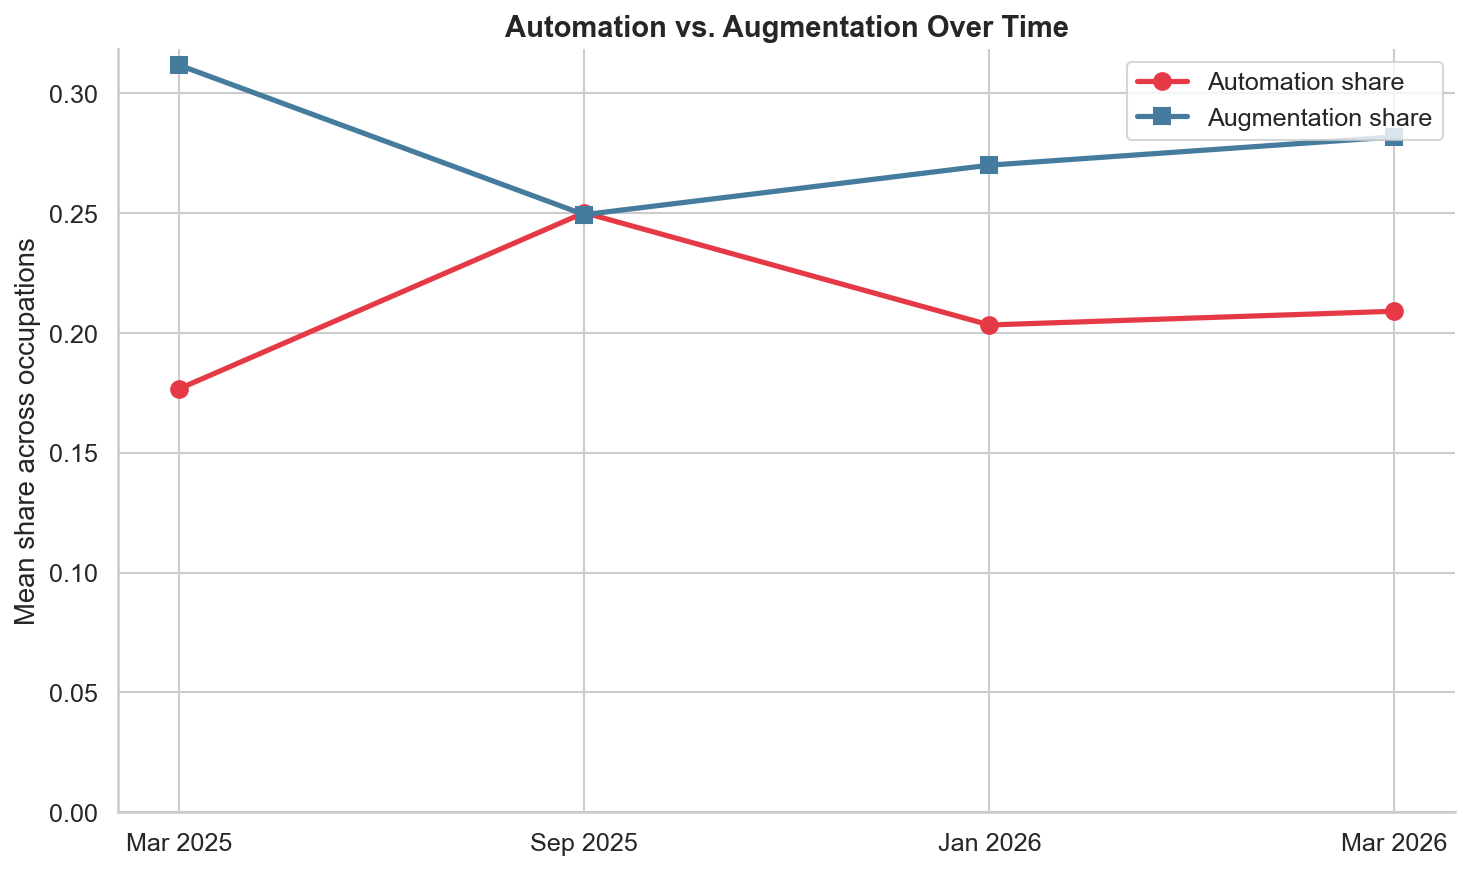

In [3]:
agg_by_release = (
    panel.groupby("release")[["automation_share", "augmentation_share"]]
    .mean()
    .reindex(RELEASE_ORDER)
)

fig, ax = plt.subplots(figsize=(10, 6))
release_labels = ["Mar 2025", "Sep 2025", "Jan 2026", "Mar 2026"]
x = range(len(release_labels))

ax.plot(x, agg_by_release["automation_share"], "o-", color=COLORS["automation"],
        linewidth=2.5, markersize=8, label="Automation share")
ax.plot(x, agg_by_release["augmentation_share"], "s-", color=COLORS["augmentation"],
        linewidth=2.5, markersize=8, label="Augmentation share")

ax.set_xticks(x)
ax.set_xticklabels(release_labels)
ax.set_ylabel("Mean share across occupations")
ax.set_title("Automation vs. Augmentation Over Time", fontsize=14, fontweight="bold")
ax.legend(frameon=True, loc="upper right")
ax.set_ylim(0, None)
sns.despine()
plt.tight_layout()
plt.savefig("../figures/01_automation_vs_augmentation_trend.png", bbox_inches="tight")
plt.show()

## Distribution of automation share across occupations

Most occupations cluster at low automation shares, but there's a long right tail.

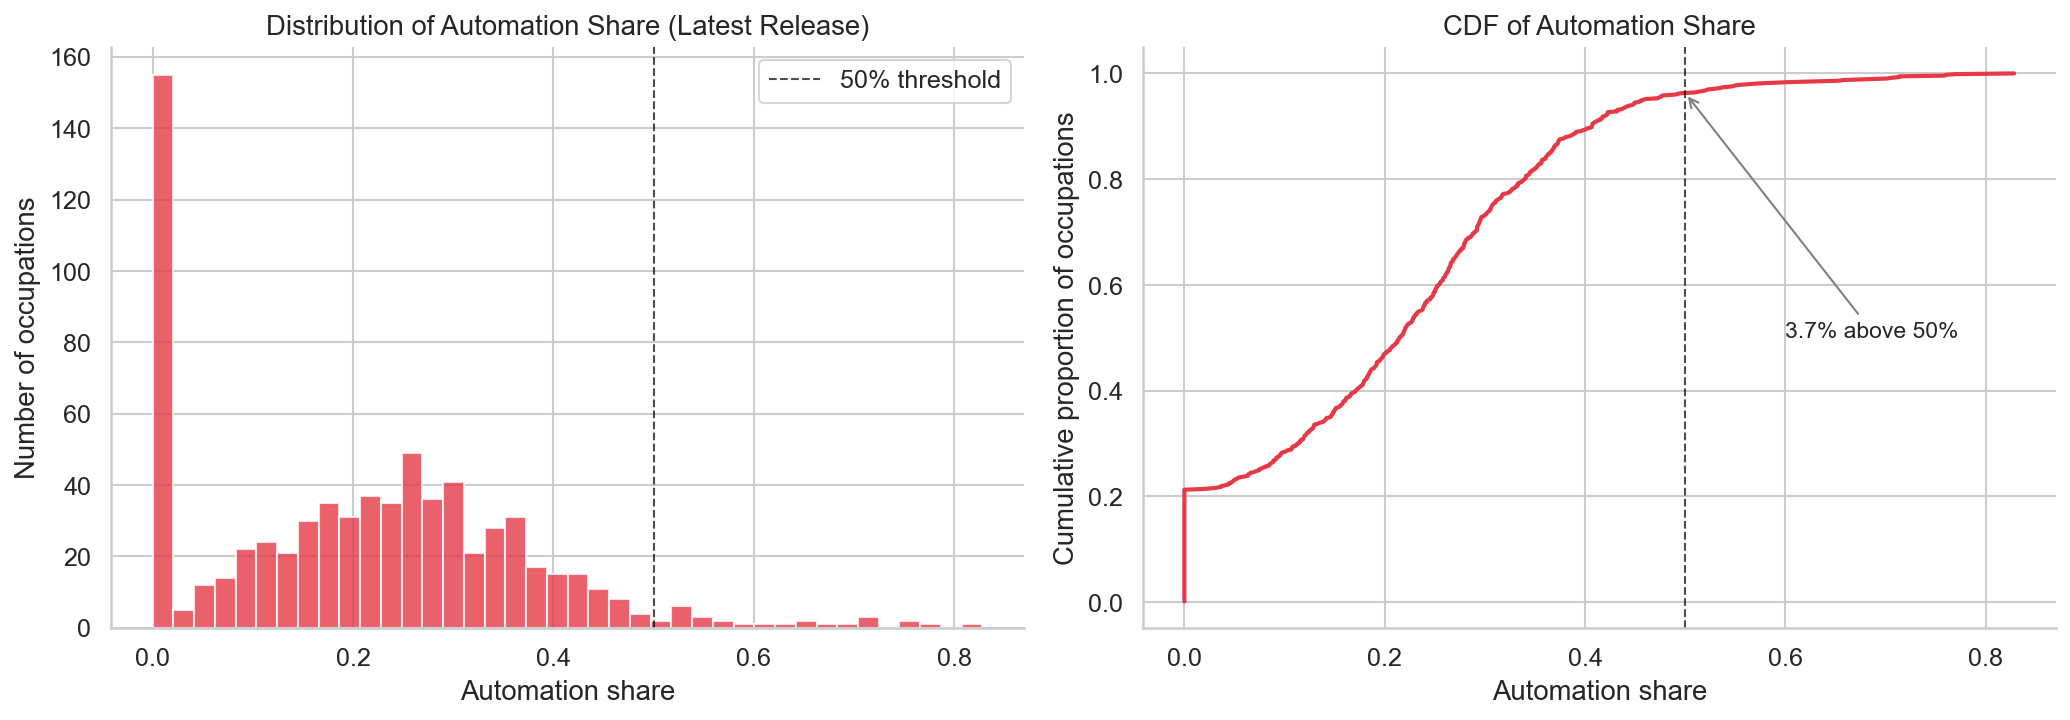

In [4]:
latest = panel[panel["release"] == RELEASE_ORDER[-1]].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(latest["automation_share"], bins=40, color=COLORS["automation"],
             alpha=0.8, edgecolor="white")
axes[0].axvline(0.5, color="black", linestyle="--", linewidth=1, alpha=0.7, label="50% threshold")
axes[0].set_xlabel("Automation share")
axes[0].set_ylabel("Number of occupations")
axes[0].set_title("Distribution of Automation Share (Latest Release)")
axes[0].legend()

# CDF
sorted_shares = np.sort(latest["automation_share"].dropna())
cdf = np.arange(1, len(sorted_shares) + 1) / len(sorted_shares)
axes[1].plot(sorted_shares, cdf, color=COLORS["automation"], linewidth=2)
axes[1].axvline(0.5, color="black", linestyle="--", linewidth=1, alpha=0.7)
axes[1].set_xlabel("Automation share")
axes[1].set_ylabel("Cumulative proportion of occupations")
axes[1].set_title("CDF of Automation Share")

pct_above_50 = (latest["automation_share"] >= 0.5).mean()
axes[1].annotate(f"{pct_above_50:.1%} above 50%",
                 xy=(0.5, 1 - pct_above_50), fontsize=11,
                 xytext=(0.6, 0.5), arrowprops=dict(arrowstyle="->", color="gray"))

sns.despine()
plt.tight_layout()
plt.savefig("../figures/02_automation_share_distribution.png", bbox_inches="tight")
plt.show()

## Which occupations have the highest automation share?

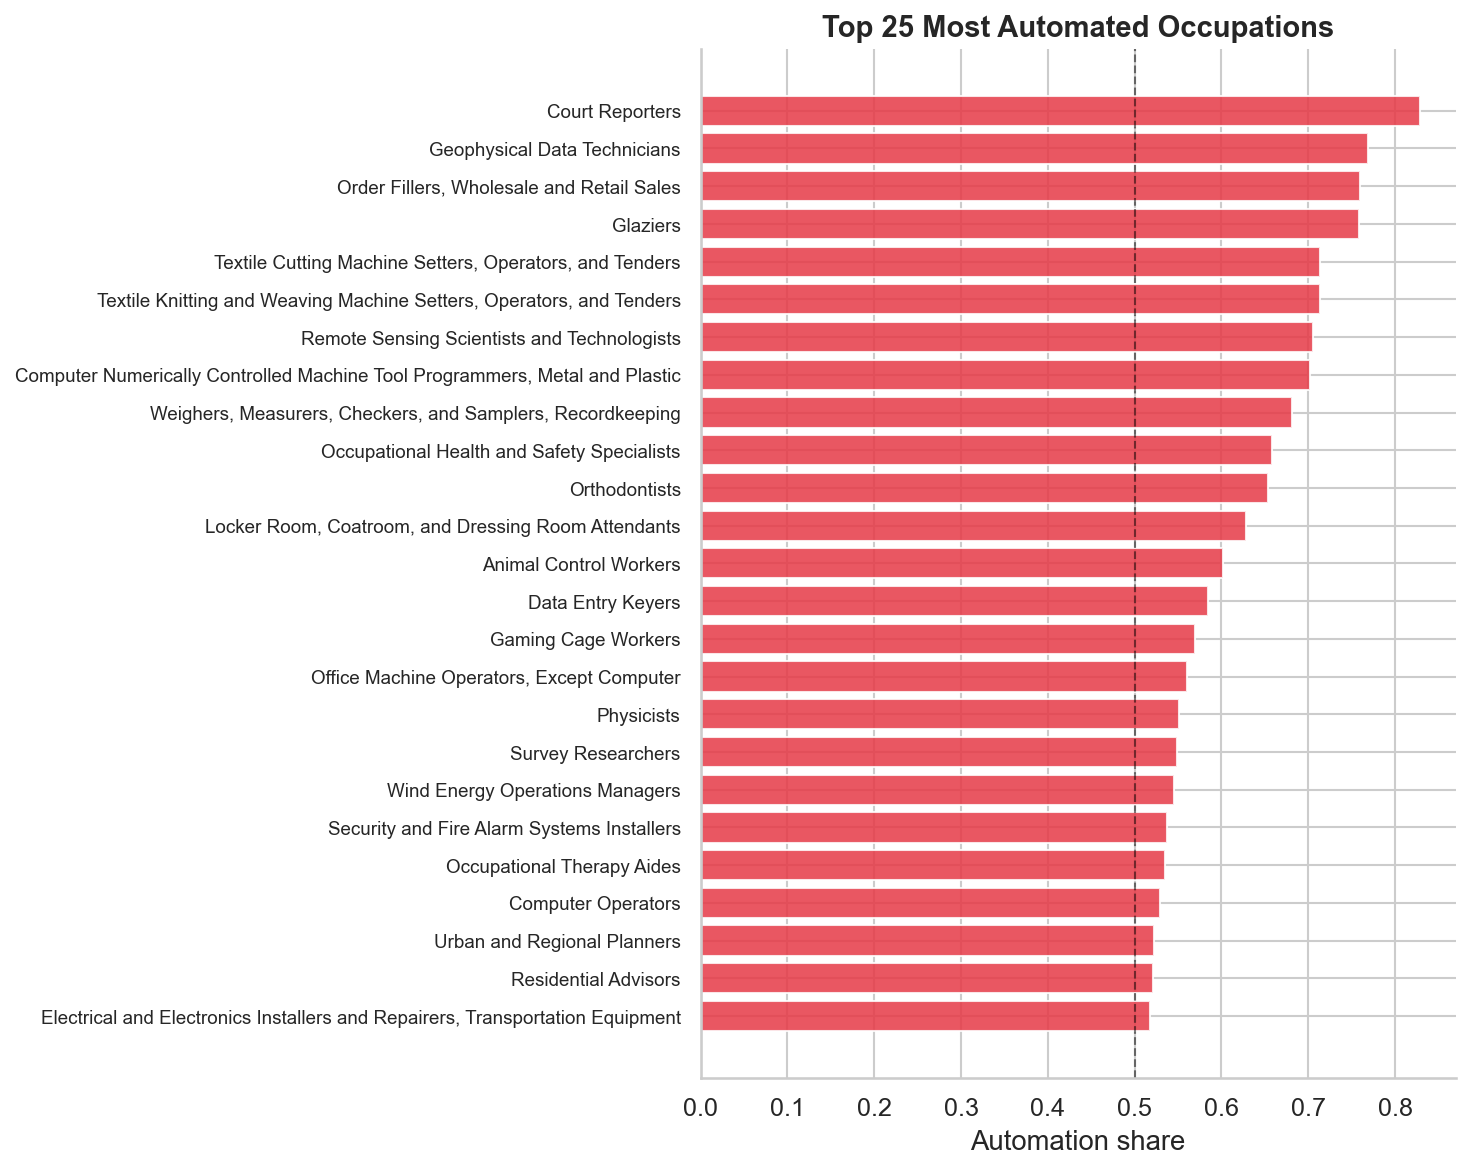

In [5]:
# Top 25 most automated occupations in the latest release
top_auto = latest.nlargest(25, "automation_share")[["title", "automation_share", "mediansalary"]]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(range(len(top_auto)), top_auto["automation_share"],
               color=COLORS["automation"], alpha=0.85, edgecolor="white")
ax.set_yticks(range(len(top_auto)))
ax.set_yticklabels(top_auto["title"].values, fontsize=9)
ax.set_xlabel("Automation share")
ax.set_title("Top 25 Most Automated Occupations", fontsize=14, fontweight="bold")
ax.axvline(0.5, color="black", linestyle="--", linewidth=1, alpha=0.5)
ax.invert_yaxis()
sns.despine()
plt.tight_layout()
plt.savefig("../figures/03_top_automated_occupations.png", bbox_inches="tight")
plt.show()

## Automation velocity: which occupations are shifting fastest?

Velocity measures the slope of automation share across releases.
Positive velocity = moving toward more automation.

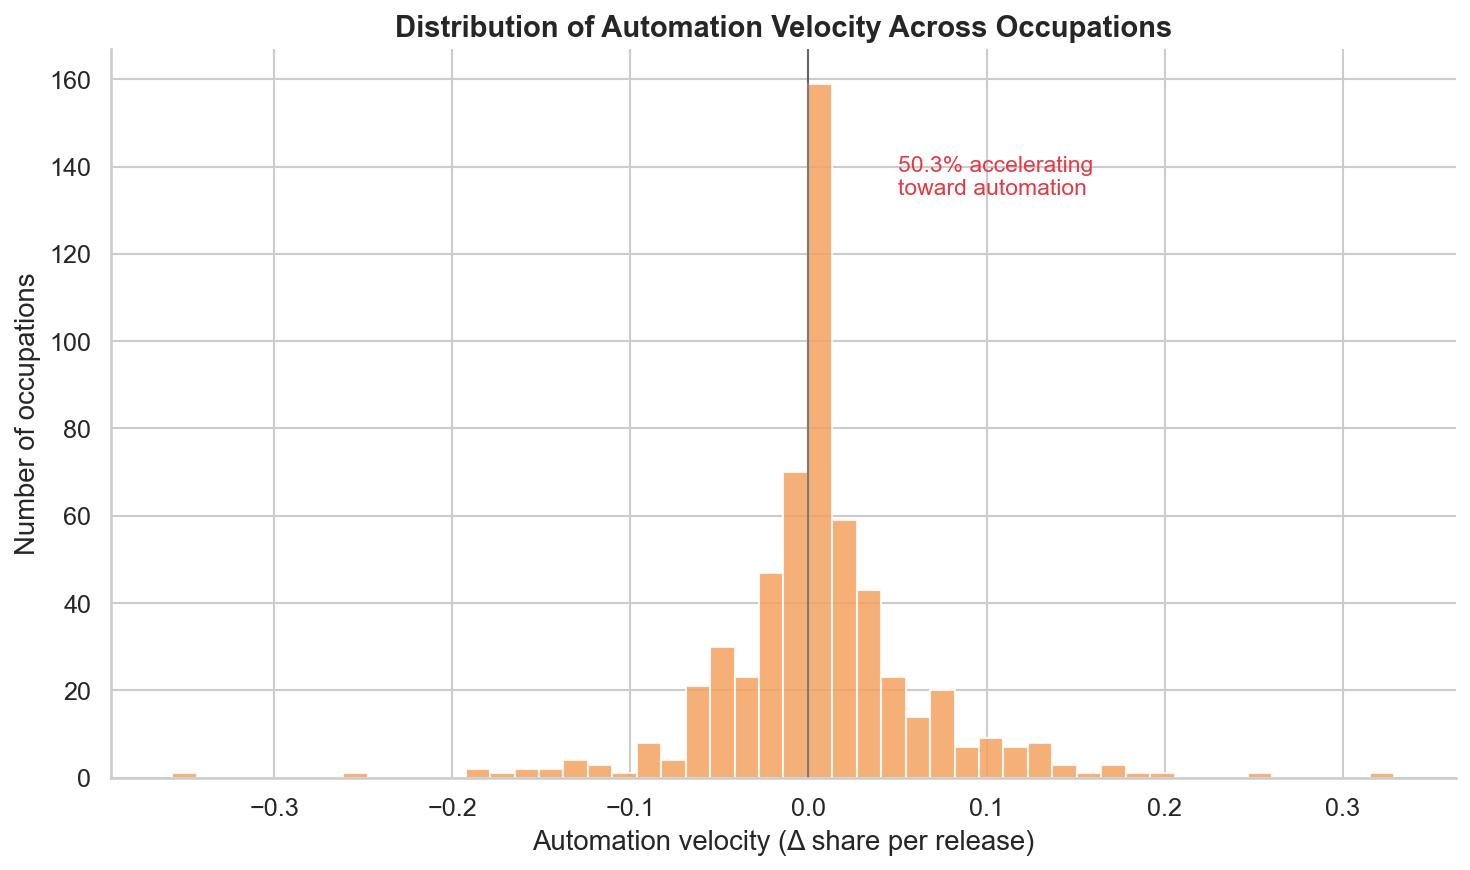

In [6]:
vel = features.dropna(subset=["automation_velocity"]).copy()

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(vel["automation_velocity"], bins=50, color=COLORS["accent"],
        alpha=0.85, edgecolor="white")
ax.axvline(0, color="black", linestyle="-", linewidth=1, alpha=0.5)
ax.set_xlabel("Automation velocity (Δ share per release)")
ax.set_ylabel("Number of occupations")
ax.set_title("Distribution of Automation Velocity Across Occupations", fontsize=14, fontweight="bold")

pct_positive = (vel["automation_velocity"] > 0).mean()
ax.annotate(f"{pct_positive:.1%} accelerating\ntoward automation",
            xy=(0.05, ax.get_ylim()[1] * 0.8), fontsize=11, color=COLORS["automation"])

sns.despine()
plt.tight_layout()
plt.savefig("../figures/04_automation_velocity_distribution.png", bbox_inches="tight")
plt.show()

## The Jagged Adoption Frontier

Inspired by Dell'Acqua et al.'s "jagged technological frontier," we plot each
occupation's *expected* automation share (based on wage, a proxy for task complexity)
against its *actual* automation share.

Occupations **above the diagonal** are automating faster than their wage level would predict.
Occupations **below** are resisting automation despite being in the expected range.

/var/folders/_k/74l7m8q96c70qsmn56rqh_zc0000gq/T/ipykernel_73991/2570807910.py:32: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from current font.
  plt.tight_layout()
/var/folders/_k/74l7m8q96c70qsmn56rqh_zc0000gq/T/ipykernel_73991/2570807910.py:32: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from current font.
  plt.tight_layout()
/var/folders/_k/74l7m8q96c70qsmn56rqh_zc0000gq/T/ipykernel_73991/2570807910.py:33: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from current font.
  plt.savefig("../figures/05_jagged_adoption_frontier.png", bbox_inches="tight")
/var/folders/_k/74l7m8q96c70qsmn56rqh_zc0000gq/T/ipykernel_73991/2570807910.py:33: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from current font.
  plt.savefig("../figures/05_jagged_adoption_frontier.png", bbox_inches="tight")
/Users/alvin/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from current font.
  fig.canvas.print_figu

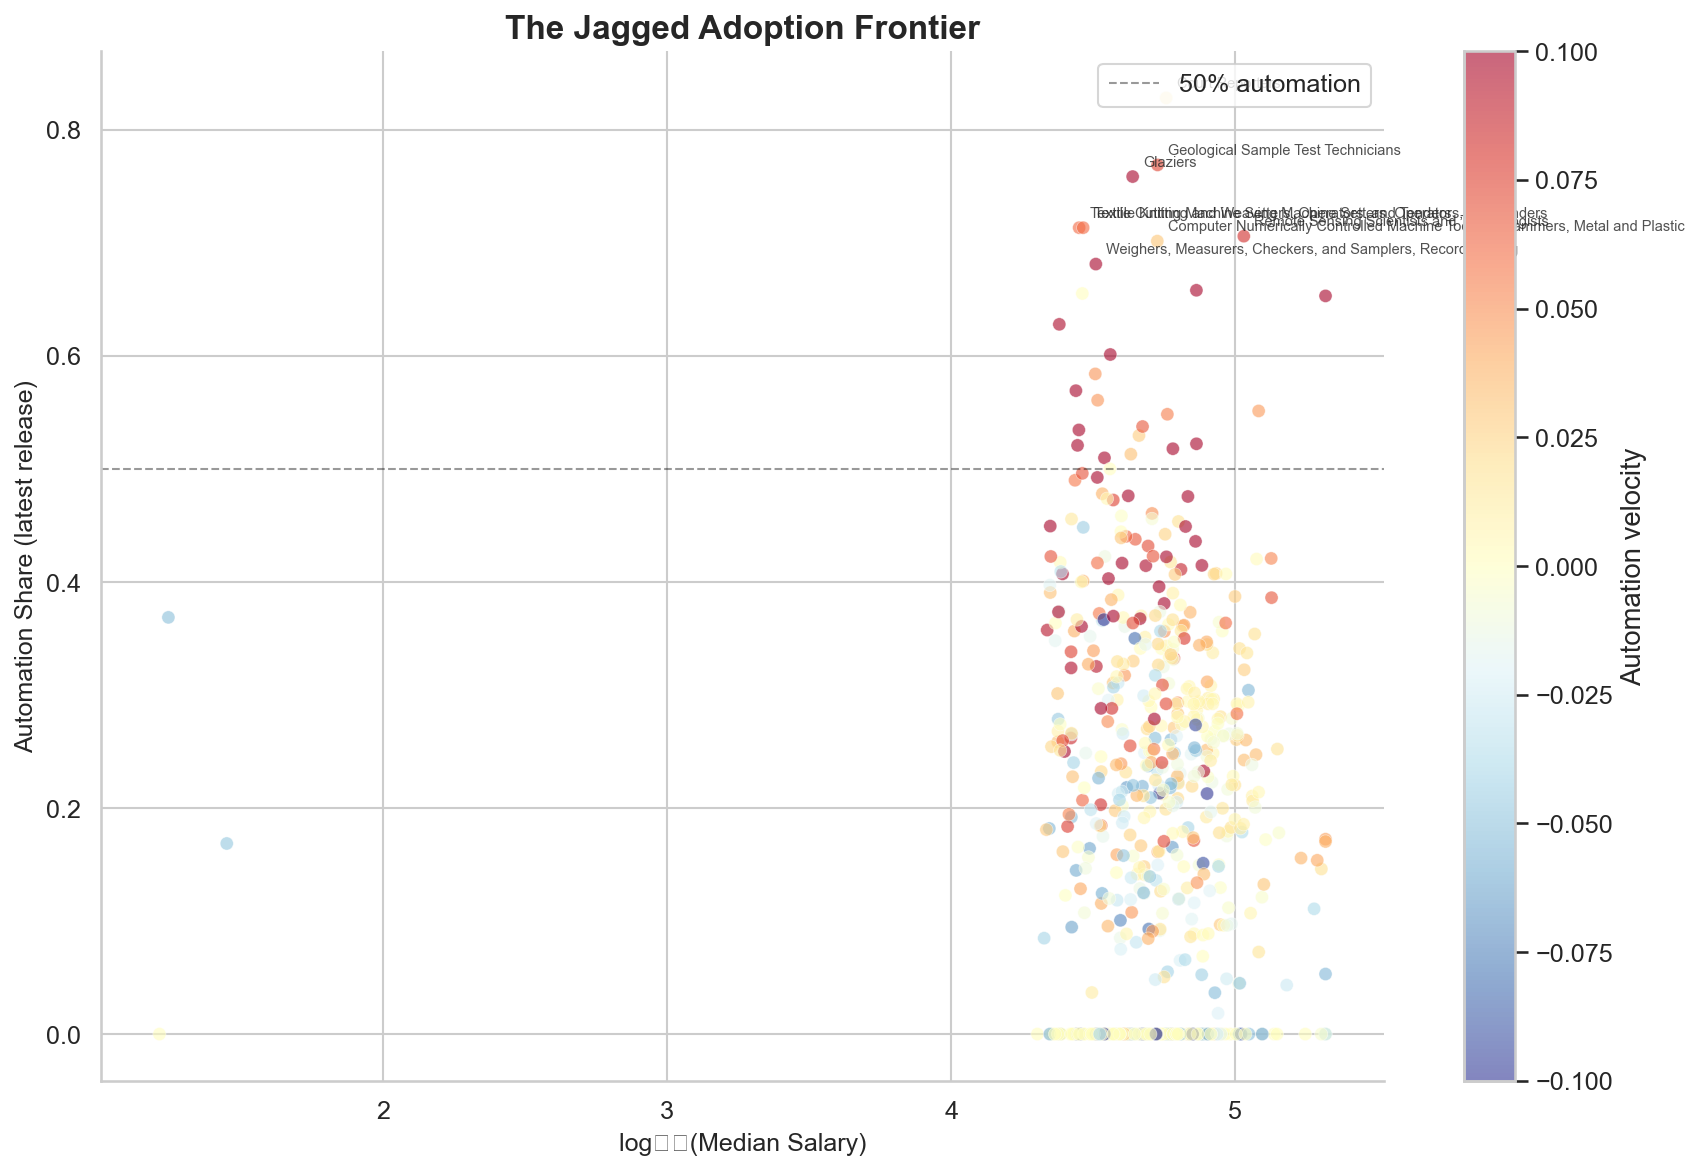

In [7]:
plot_df = features.dropna(subset=["mediansalary", "latest_automation_share"]).copy()
plot_df["log_salary"] = np.log10(plot_df["mediansalary"].clip(lower=1))

fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(
    plot_df["log_salary"],
    plot_df["latest_automation_share"],
    c=plot_df["automation_velocity"].fillna(0),
    cmap="RdYlBu_r",
    s=40,
    alpha=0.6,
    edgecolors="white",
    linewidth=0.3,
    vmin=-0.1,
    vmax=0.1,
)
cbar = plt.colorbar(scatter, ax=ax, label="Automation velocity")

ax.axhline(0.5, color="black", linestyle="--", linewidth=1, alpha=0.4, label="50% automation")

# Annotate notable occupations
for _, row in plot_df.nlargest(8, "latest_automation_share").iterrows():
    ax.annotate(row["title"], (row["log_salary"], row["latest_automation_share"]),
                fontsize=7, alpha=0.8, xytext=(5, 5), textcoords="offset points")

ax.set_xlabel("log₁₀(Median Salary)", fontsize=12)
ax.set_ylabel("Automation Share (latest release)", fontsize=12)
ax.set_title("The Jagged Adoption Frontier", fontsize=16, fontweight="bold")
ax.legend(loc="upper right")
sns.despine()
plt.tight_layout()
plt.savefig("../figures/05_jagged_adoption_frontier.png", bbox_inches="tight")
plt.show()

## Collaboration mode breakdown by wage quartile

How do the five collaboration modes distribute across the wage spectrum?

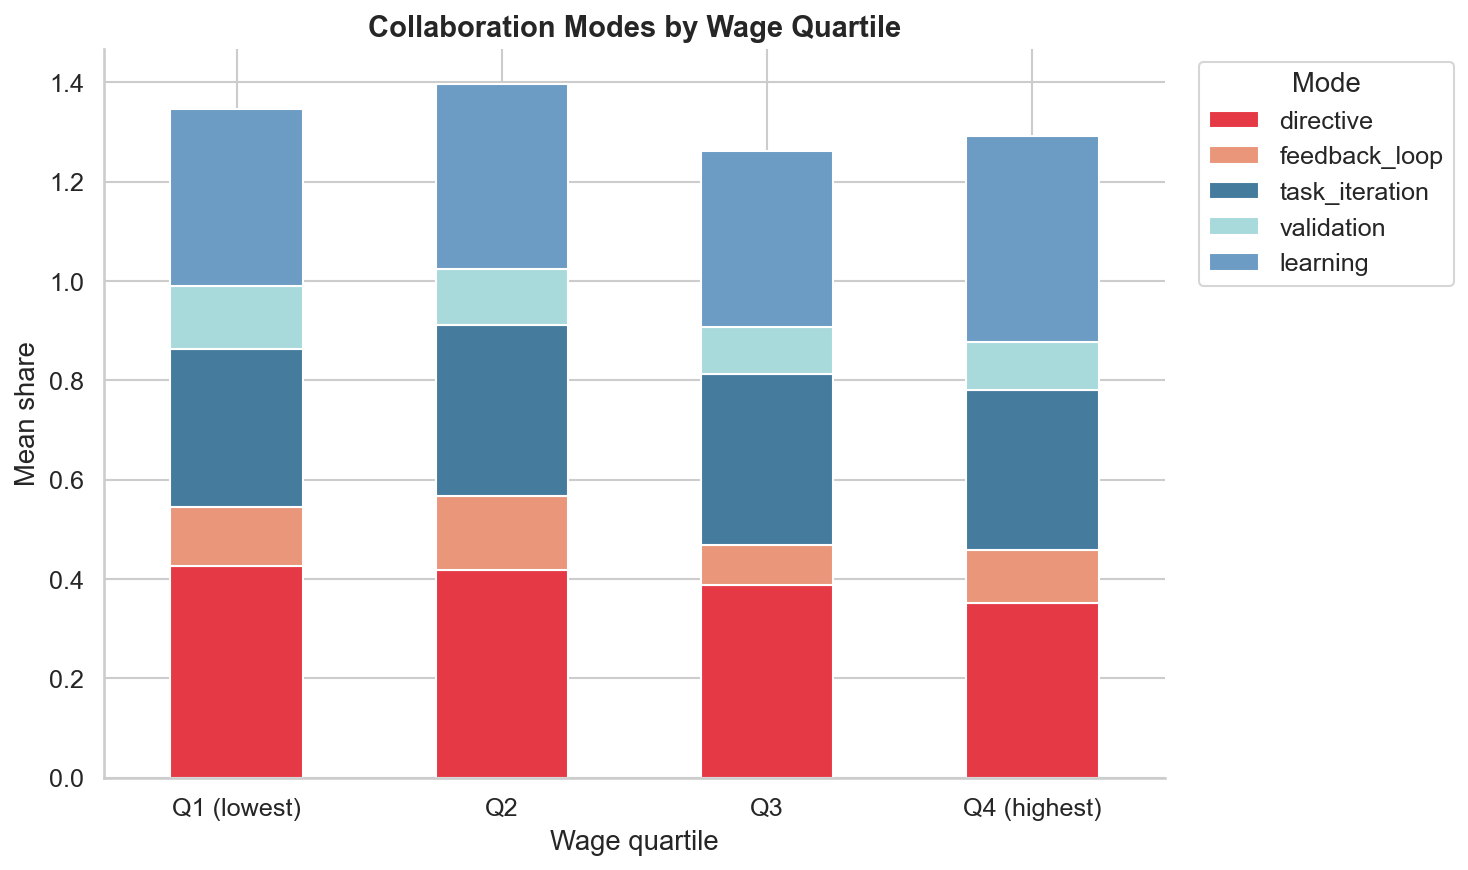

In [8]:
latest_w = latest.dropna(subset=["mediansalary"]).copy()
latest_w["wage_quartile"] = pd.qcut(latest_w["mediansalary"], 4,
                                     labels=["Q1 (lowest)", "Q2", "Q3", "Q4 (highest)"])

modes = ["directive", "feedback_loop", "task_iteration", "validation", "learning"]
mode_by_wage = latest_w.groupby("wage_quartile")[modes].mean()

fig, ax = plt.subplots(figsize=(10, 6))
mode_by_wage.plot(kind="bar", stacked=True, ax=ax,
                  color=[COLORS["automation"], "#E9967A", COLORS["augmentation"], "#A8DADC", "#6C9BC4"])
ax.set_ylabel("Mean share")
ax.set_xlabel("Wage quartile")
ax.set_title("Collaboration Modes by Wage Quartile", fontsize=14, fontweight="bold")
ax.legend(title="Mode", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
sns.despine()
plt.tight_layout()
plt.savefig("../figures/06_modes_by_wage_quartile.png", bbox_inches="tight")
plt.show()

## Automation share vs. observed exposure

Anthropic's observed exposure metric combines theoretical LLM capability with actual
Claude usage frequency. How well does it predict the automation share we observe?

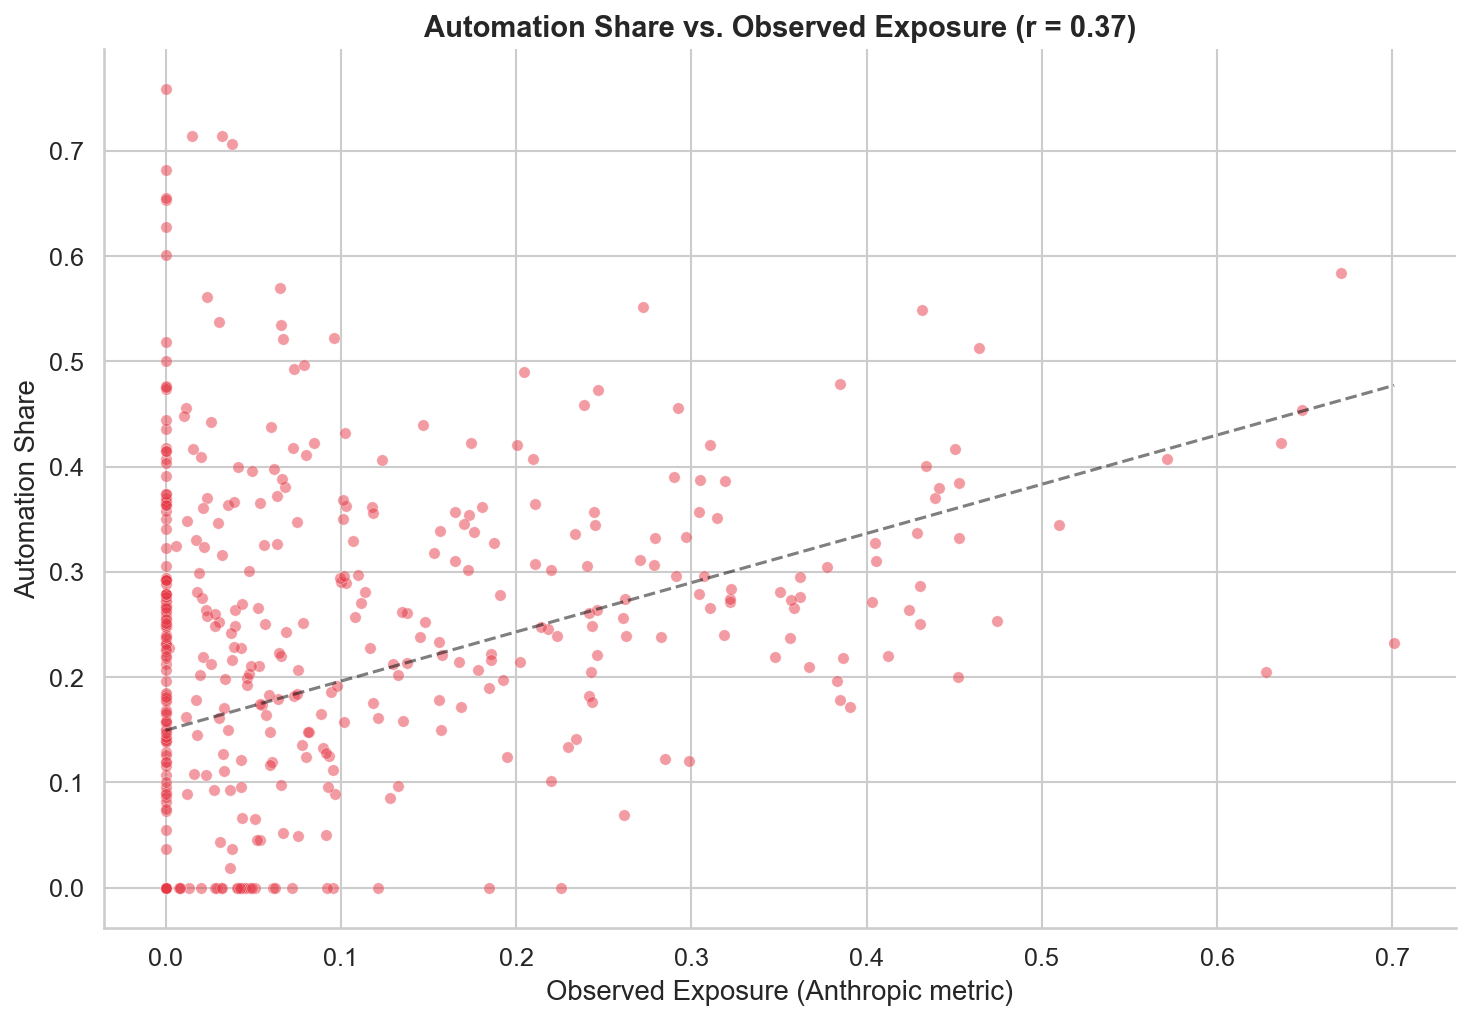

In [9]:
exp_df = features.dropna(subset=["observed_exposure", "latest_automation_share"]).copy()

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(exp_df["observed_exposure"], exp_df["latest_automation_share"],
           alpha=0.5, s=30, color=COLORS["automation"], edgecolors="white", linewidth=0.3)

# Add trend line
z = np.polyfit(exp_df["observed_exposure"], exp_df["latest_automation_share"], 1)
p = np.poly1d(z)
x_line = np.linspace(exp_df["observed_exposure"].min(), exp_df["observed_exposure"].max(), 100)
ax.plot(x_line, p(x_line), "--", color="black", alpha=0.5, linewidth=1.5)

corr = exp_df["observed_exposure"].corr(exp_df["latest_automation_share"])
ax.set_xlabel("Observed Exposure (Anthropic metric)")
ax.set_ylabel("Automation Share")
ax.set_title(f"Automation Share vs. Observed Exposure (r = {corr:.2f})",
             fontsize=14, fontweight="bold")
sns.despine()
plt.tight_layout()
plt.savefig("../figures/07_automation_vs_exposure.png", bbox_inches="tight")
plt.show()

## Correlation matrix of key features

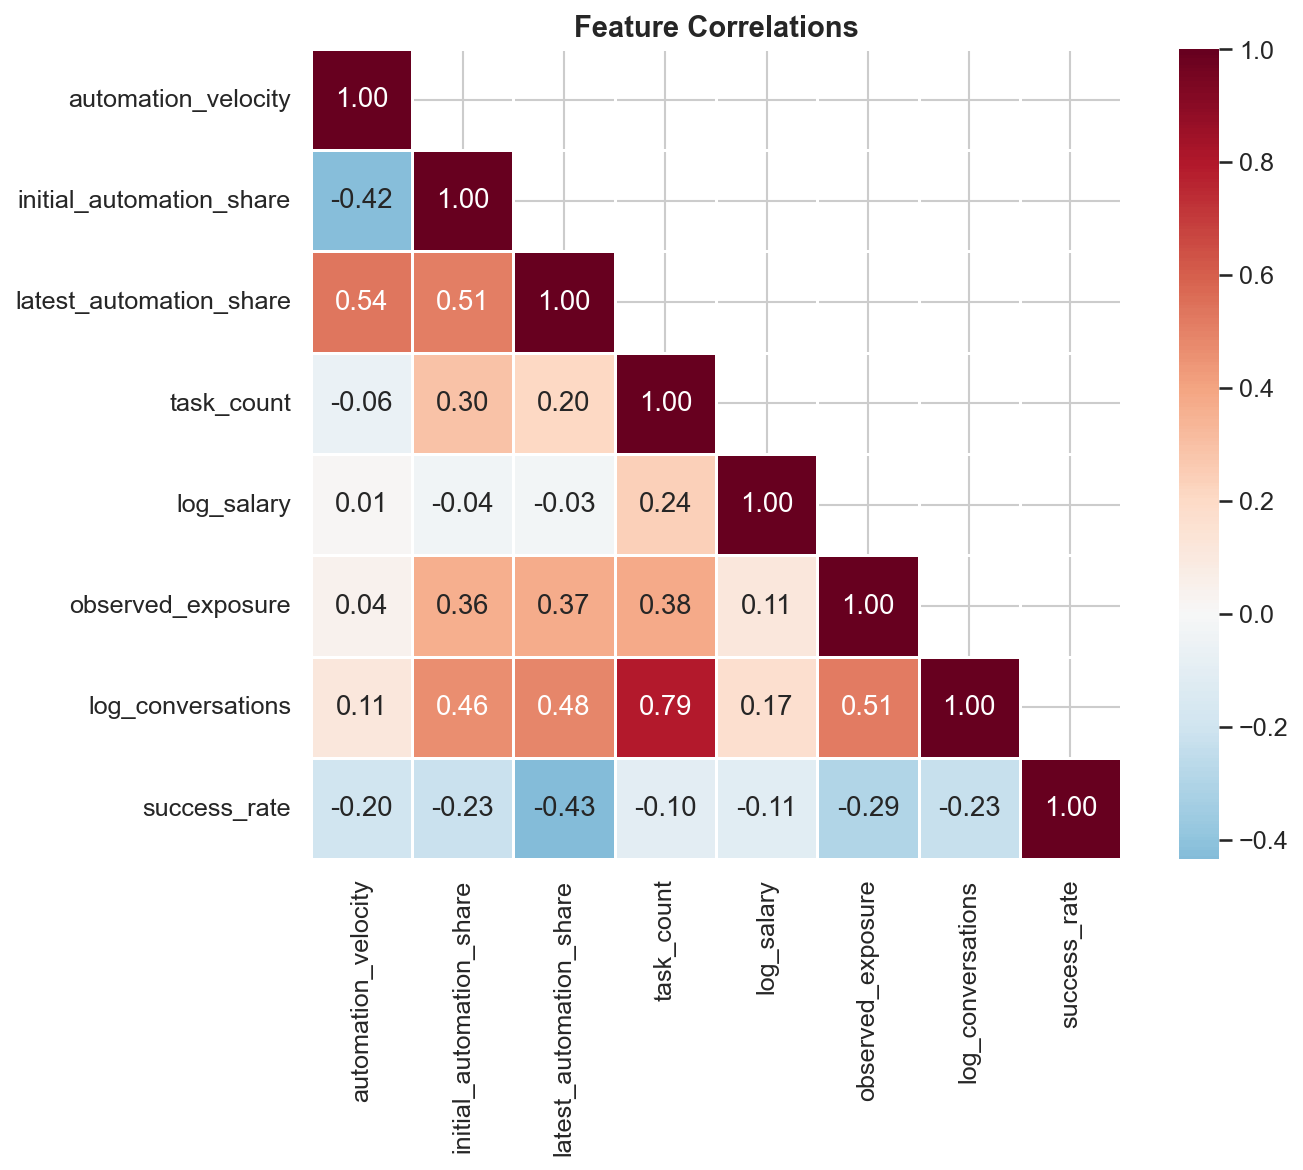

In [10]:
corr_cols = [
    "automation_velocity", "initial_automation_share", "latest_automation_share",
    "task_count", "log_salary", "observed_exposure", "log_conversations",
    "success_rate",
]
corr_cols = [c for c in corr_cols if c in features.columns]
corr_matrix = features[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, square=True, ax=ax, linewidths=0.5)
ax.set_title("Feature Correlations", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../figures/08_correlation_matrix.png", bbox_inches="tight")
plt.show()

---

**Key takeaways from EDA:**
1. Most occupations remain augmentation-dominant, but a meaningful tail has crossed 50%
2. There's significant variation in automation velocity — the transition is not uniform
3. Wage is a weak predictor of automation share, creating a genuinely "jagged" frontier
4. Conversation volume and initial automation share are the strongest correlates of velocity

**Next:** [03_modeling.ipynb](03_modeling.ipynb) — Predictive models for the automation tipping point.